In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbPipeline

sns.set(style="whitegrid")

## 1. EDA

1.1 Data exploration

In [73]:
df = pd.read_csv("/Users/adilkhankaldybekov/Desktop/adilkhan/Machine Learning/courses/project 1/data.csv", sep=';')

In [74]:
#Data Set observation

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [119]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [76]:
#Counting number of nan values for each feature

print(df.isna().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [77]:
#Data observation for integer features

num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].describe()



,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#### 1.2 Data visualization

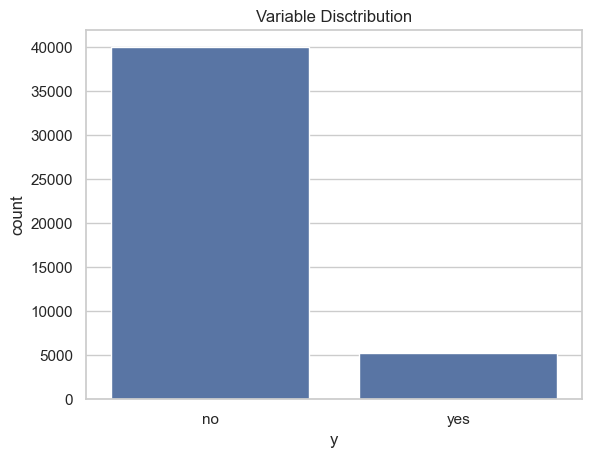

In [78]:
#Disctribution of all target values in dataset
sns.countplot(x='y', data=df)
plt.title('Variable Disctribution')
plt.show()

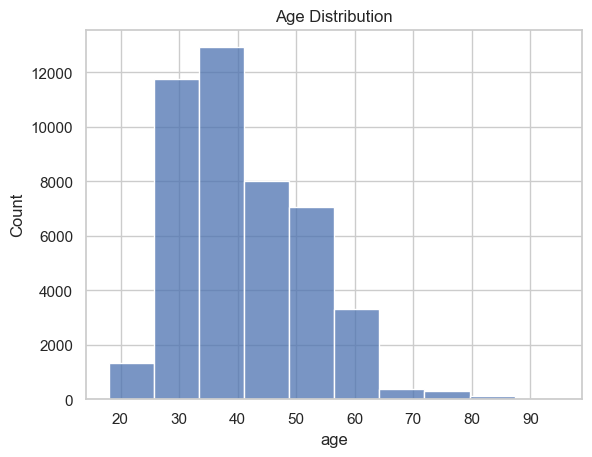

In [79]:
# Visualizing the distribution of 'age' column
sns.histplot(df['age'], bins=10)
plt.title('Age Distribution')
plt.show()

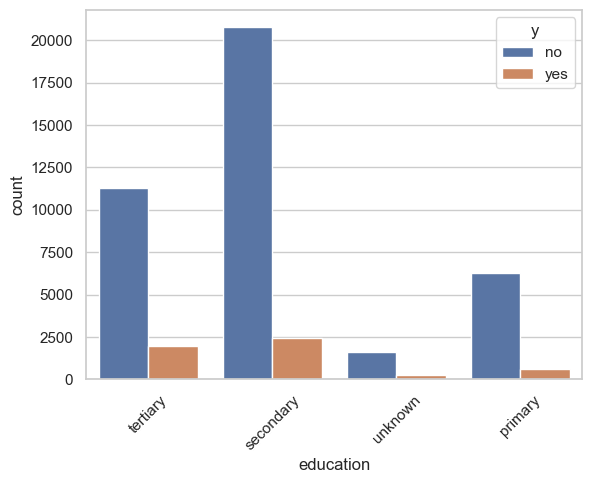

In [80]:
#Comparing of all education levels by target value

sns.countplot(x='education', hue='y', data=df)
plt.xticks(rotation=45)
plt.show()

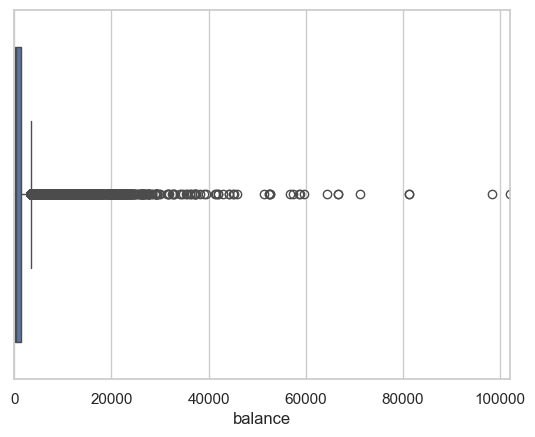

In [81]:
sns.boxplot(x=df['balance'])
plt.xlim(0, df['balance'].max())
plt.show()

#### 1.3 Correlation Analysis

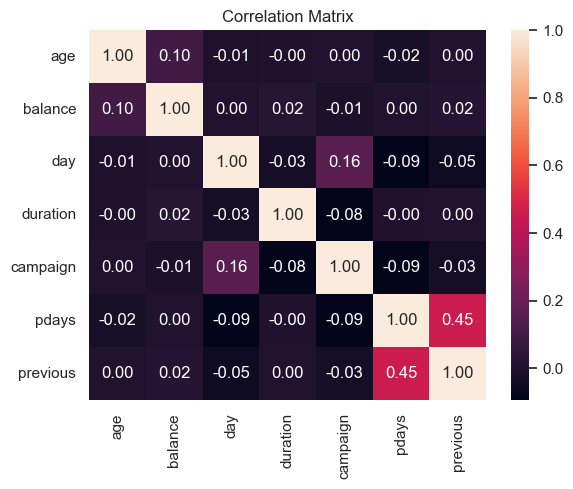

In [82]:
#looking at the relation between numerical features
correlation = df[num_cols].corr()
sns.heatmap(correlation, annot=True,fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 2. Data processing/engineering ##

In [83]:
cat_cols = df.select_dtypes(include=['object']).drop(columns=['y']).columns

In [84]:
def create_prep():
    num_transformer = Pipeline(steps=[('scaler', StandardScaler())]) #for ranging variables

    cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]) #for categorical variables one-hot encoding  

    prep = ColumnTransformer(transformers=[('num', num_transformer, num_cols),
                                           ('cat', cat_transformer, cat_cols)])
    return prep

preprocessor = create_prep() 

According to some observations we did data exploratory analysis and feature engineering engineering(Standardize data and Encoding)

## 2. Model Building (Построение моделей)

#### 3.1 Logistic Regression

In [85]:
X = df.drop(columns='y', axis=1)


Y = (df['y'] == 'yes').astype(int)
#Y = df['y'].map({'yes': 1, 'no' : 0})

In [86]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split( X, Y, test_size=0.2, random_state=42, stratify=Y)

In [87]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('logreg',LogisticRegression(random_state=42, max_iter=1000))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]


print("Distribuition of values after SMOTE:")
Xsmote, Ysmote = pipe.named_steps['smote'].fit_resample(preprocessor.fit_transform(Xtrain), Ytrain)
print(Ysmote.value_counts())

Distribuition of values after SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64


Evaluating

In [88]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.97      0.85      0.91      7985
         Yes       0.42      0.80      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043

ROC AUC : 0.91


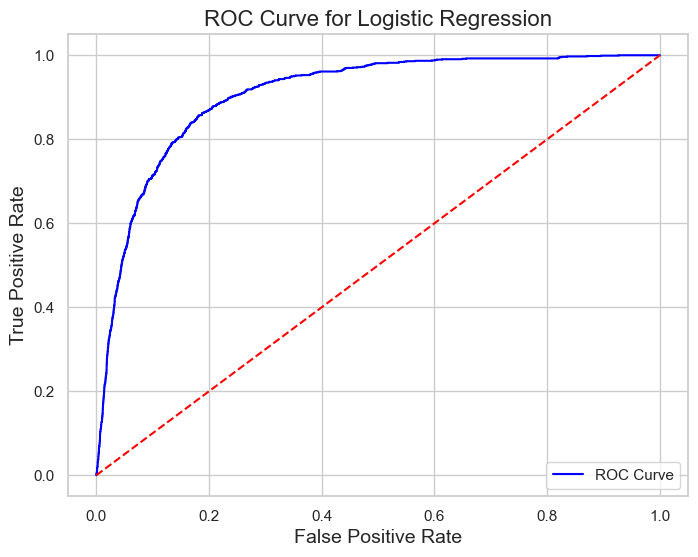

In [89]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for Logistic Regression', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


### Model Evaluation:

- **Accuracy:** Good overall, predicts the majority class well
- **Precision:** Low - many false positives
- **Recall:** Good due to SMOTE
- **ROC AUC:** Normal, but not high


#### 3.2 Decision Tree

In [90]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('DecTrees',DecisionTreeClassifier(random_state=42))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]




In [91]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.94      0.91      0.92      7985
         Yes       0.44      0.54      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.72      0.70      9043
weighted avg       0.88      0.87      0.87      9043

ROC AUC : 0.72


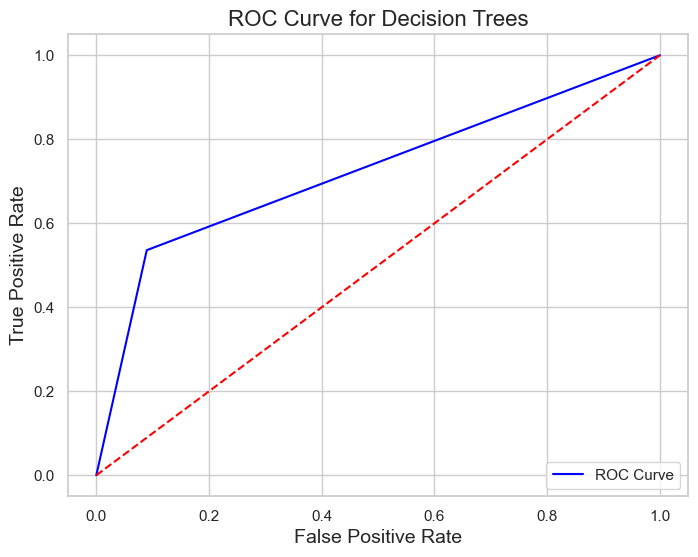

In [92]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for Decision Trees', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


### Model Evaluation:

- **Accuracy:** Higher than Logistic Regression
- **Precision & Recall:** Low grade, Big possibility of Overfitting
- **ROC AUC:** Normal, but not high


In General, This model is prone to overfitting since there is a possibility that Decision Tree learnt many nonlinear patterns

#### 3.3 Random Forest

In [93]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('RanFor',RandomForestClassifier(random_state=42))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]


In [94]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.94      0.95      0.94      7985
         Yes       0.58      0.55      0.56      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.75      0.75      9043
weighted avg       0.90      0.90      0.90      9043

ROC AUC : 0.93


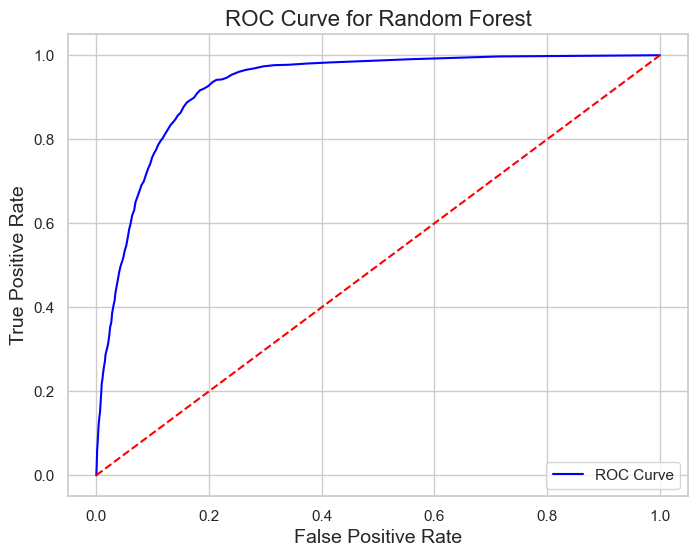

In [95]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for Random Forest', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


### Model Evaluation:

In General, This model did better than Decision Trees

#### 3.4 XGBoost

In [96]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('XGB',XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:05:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [97]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.94      0.95      0.95      7985
         Yes       0.61      0.57      0.59      1058

    accuracy                           0.91      9043
   macro avg       0.78      0.76      0.77      9043
weighted avg       0.90      0.91      0.91      9043

ROC AUC : 0.93


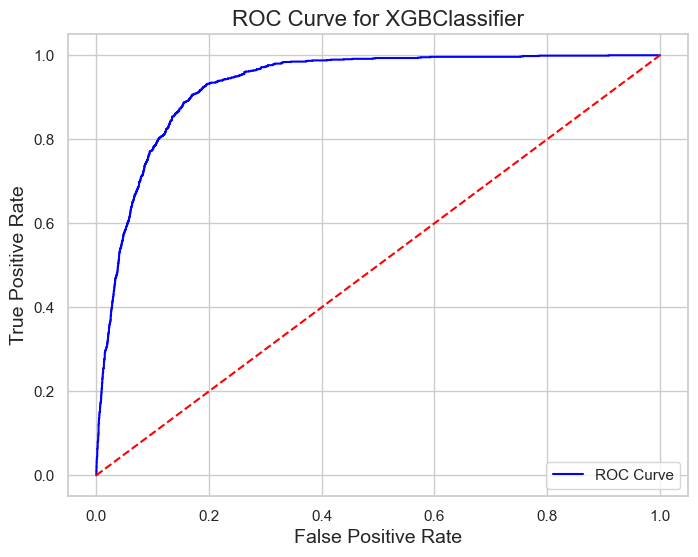

In [98]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for XGBClassifier', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


Comparing with previous model, for now, results are the best

#### 3.5 CatBoost

In [99]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('CatBoost',CatBoostClassifier(verbose=0, random_state=42))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]


In [100]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.94      0.96      0.95      7985
         Yes       0.63      0.57      0.60      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.76      0.77      9043
weighted avg       0.91      0.91      0.91      9043

ROC AUC : 0.93


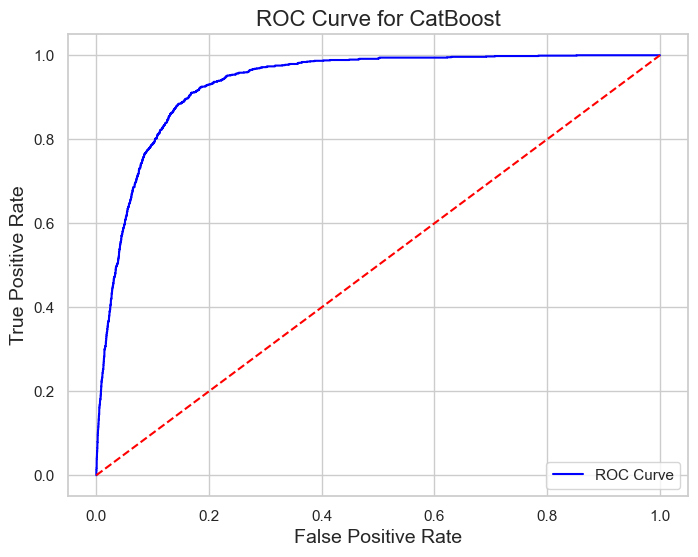

In [101]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for CatBoost', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


Good Results 

## 4. Results comparison (Сравнение результатов)

## Model Comparison

| Model | Accuracy | Precision (Yes) | Recall (Yes) | F1-score (Yes) | ROC AUC |
|---|---|---|---|---|---|
| **Logistic Regression** | 0.85 | 0.42 | **0.80** | 0.55 | 0.91 |
| **Decision Tree** | 0.87 | 0.44 | 0.54 | 0.48 | 0.72 |
| **Random Forest** | 0.90 | 0.58 | 0.55 | 0.56 | **0.93** |
| **XGBoost** | **0.91** | **0.68** | 0.57 | 0.59 | **0.93** |
| **CatBoost** | **0.91** | 0.63 | 0.57 | **0.60** | **0.93** |


---


### **Strengths and Weaknesses**

1. **Logistic Regression**
   - **Strengths:** High recall (0.80), simple, fast, easy to interpret.
   - **Weaknesses:** Low precision (0.42), misses specificity, cannot model nonlinear relationships.

2. **Decision Tree**
   - **Strengths:** Slightly better accuracy than LR, easy interpretability.
   - **Weaknesses:** Lowest ROC AUC (0.72), overfits easily, weak generalization.

3. **Random Forest**
   - **Strengths:** High accuracy (0.90), good precision (0.58), excellent ROC AUC (0.93), reduces overfitting compared to a single tree.
   - **Weaknesses:** Less interpretable, longer training time than LR or single tree.

4. **XGBoost**
   - **Strengths:** Highest precision (0.68), high accuracy (0.91), strong F1-score (0.59), excellent ROC AUC (0.93), handles complex data well.
   - **Weaknesses:** Requires careful hyperparameter tuning, less interpretable, longer training time.

5. **CatBoost**
   - **Strengths:** Highest F1-score (0.60), high precision (0.63), high accuracy (0.91), handles categorical features natively, excellent ROC AUC (0.93).
   - **Weaknesses:** Longer training time, slightly less widespread in industry compared to XGBoost.






### **Best Model Selection**

**CatBoost is chosen as the best model** for this task because:

✔️ It achieved the **highest F1-score (0.60)**, indicating the best balance between precision and recall.  
✔️ Its precision (0.63) and recall (0.57) are both high, leading to reliable predictions.  
✔️ It handles categorical features efficiently without complex preprocessing.  
✔️ Its ROC AUC (0.93) is equal to XGBoost and Random Forest, showing strong class separation.

 **In summary:** CatBoost provides **the most balanced and robust performance** for this classification task, making it the preferred choice.

## 5. Upgrading 2 best models

5.1 CatBoost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbPipeline

sns.set(style="whitegrid")

## 1. EDA

1.1 Data exploration

In [ ]:
df = pd.read_csv("/Users/adilkhankaldybekov/Desktop/adilkhan/Machine Learning/courses/project 1/data.csv", sep=';')

In [ ]:
#Data Set observation

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
#Counting number of nan values for each feature

print(df.isna().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [ ]:
#Data observation for integer features

num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].describe()



,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#### 1.2 Data visualization

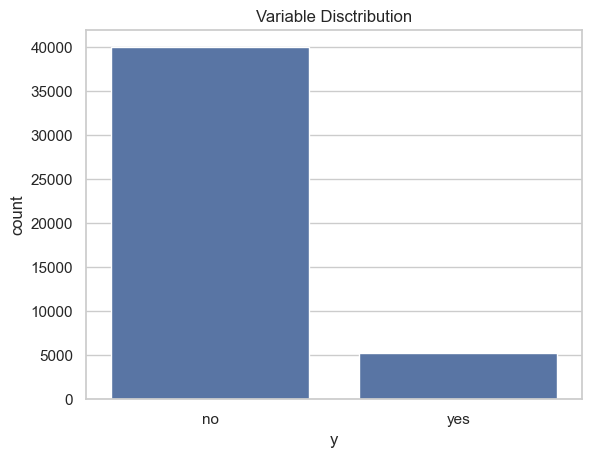

In [ ]:
#Disctribution of all target values in dataset
sns.countplot(x='y', data=df)
plt.title('Variable Disctribution')
plt.show()

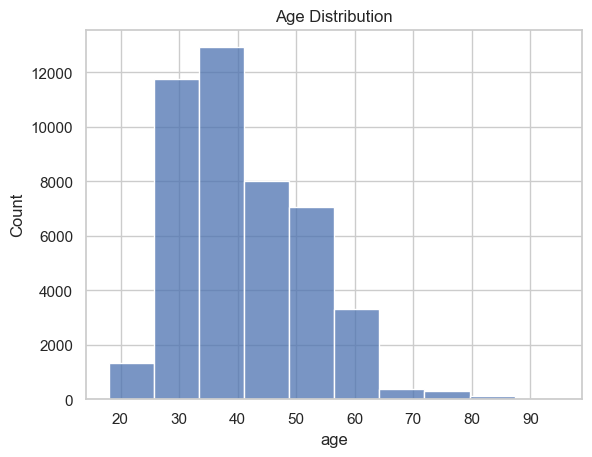

In [ ]:
# Visualizing the distribution of 'age' column
sns.histplot(df['age'], bins=10)
plt.title('Age Distribution')
plt.show()

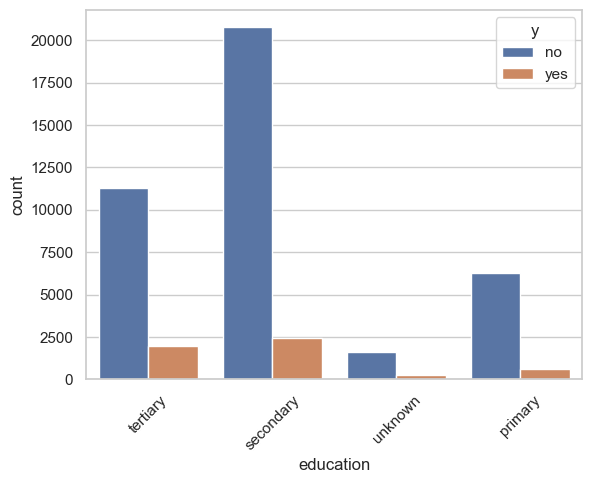

In [ ]:
#Comparing of all education levels by target value

sns.countplot(x='education', hue='y', data=df)
plt.xticks(rotation=45)
plt.show()

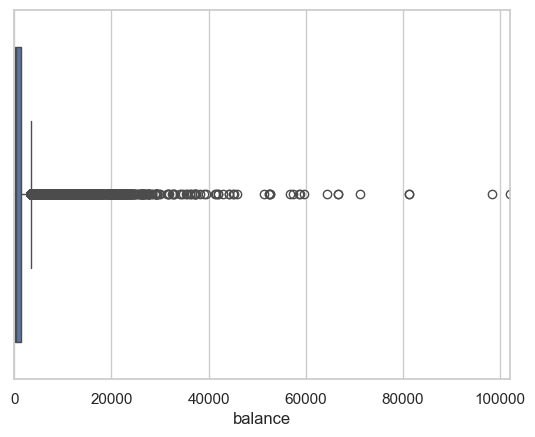

In [ ]:
sns.boxplot(x=df['balance'])
plt.xlim(0, df['balance'].max())
plt.show()

#### 1.3 Correlation Analysis

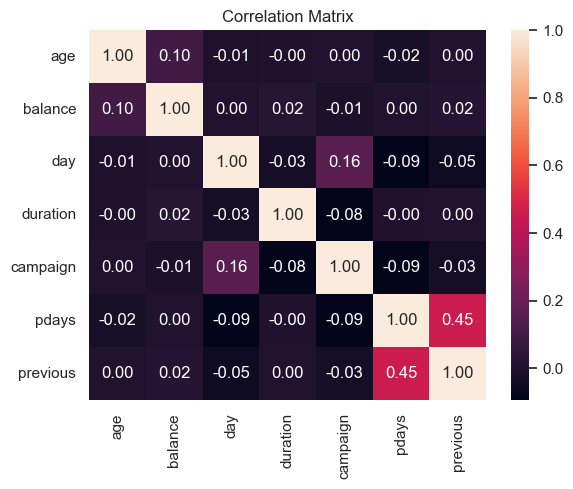

In [ ]:
#looking at the relation between numerical features
correlation = df[num_cols].corr()
sns.heatmap(correlation, annot=True,fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 2. Data processing/engineering ##

In [ ]:
cat_cols = df.select_dtypes(include=['object']).drop(columns=['y']).columns

In [ ]:
def create_prep():
    num_transformer = Pipeline(steps=[('scaler', StandardScaler())]) #for ranging variables

    cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]) #for categorical variables one-hot encoding  

    prep = ColumnTransformer(transformers=[('num', num_transformer, num_cols),
                                           ('cat', cat_transformer, cat_cols)])
    return prep

preprocessor = create_prep() 

According to some observations we did data exploratory analysis and feature engineering engineering(Standardize data and Encoding)

## 2. Model Building (Построение моделей)

#### 3.1 Logistic Regression

In [ ]:
X = df.drop(columns='y', axis=1)


Y = (df['y'] == 'yes').astype(int)
#Y = df['y'].map({'yes': 1, 'no' : 0})

In [ ]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split( X, Y, test_size=0.2, random_state=42, stratify=Y)

In [ ]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('logreg',LogisticRegression(random_state=42, max_iter=1000))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]


print("Distribuition of values after SMOTE:")
Xsmote, Ysmote = pipe.named_steps['smote'].fit_resample(preprocessor.fit_transform(Xtrain), Ytrain)
print(Ysmote.value_counts())

Distribuition of values after SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64


Evaluating

In [ ]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.97      0.85      0.91      7985
         Yes       0.42      0.80      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043

ROC AUC : 0.91


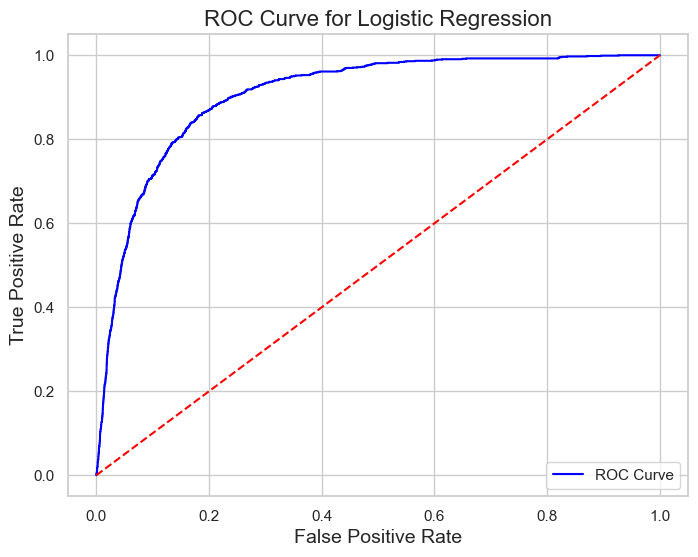

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for Logistic Regression', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


### Model Evaluation:

- **Accuracy:** Good overall, predicts the majority class well
- **Precision:** Low - many false positives
- **Recall:** Good due to SMOTE
- **ROC AUC:** Normal, but not high


#### 3.2 Decision Tree

In [ ]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('DecTrees',DecisionTreeClassifier(random_state=42))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]




In [ ]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.94      0.91      0.92      7985
         Yes       0.44      0.54      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.72      0.70      9043
weighted avg       0.88      0.87      0.87      9043

ROC AUC : 0.72


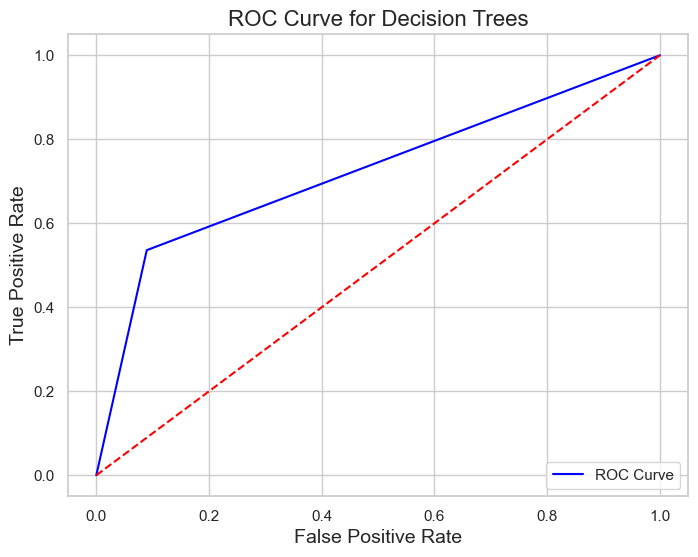

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for Decision Trees', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


### Model Evaluation:

- **Accuracy:** Higher than Logistic Regression
- **Precision & Recall:** Low grade, Big possibility of Overfitting
- **ROC AUC:** Normal, but not high


In General, This model is prone to overfitting since there is a possibility that Decision Tree learnt many nonlinear patterns

#### 3.3 Random Forest

In [ ]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('RanFor',RandomForestClassifier(random_state=42))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]


In [ ]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.94      0.95      0.94      7985
         Yes       0.58      0.55      0.56      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.75      0.75      9043
weighted avg       0.90      0.90      0.90      9043

ROC AUC : 0.93


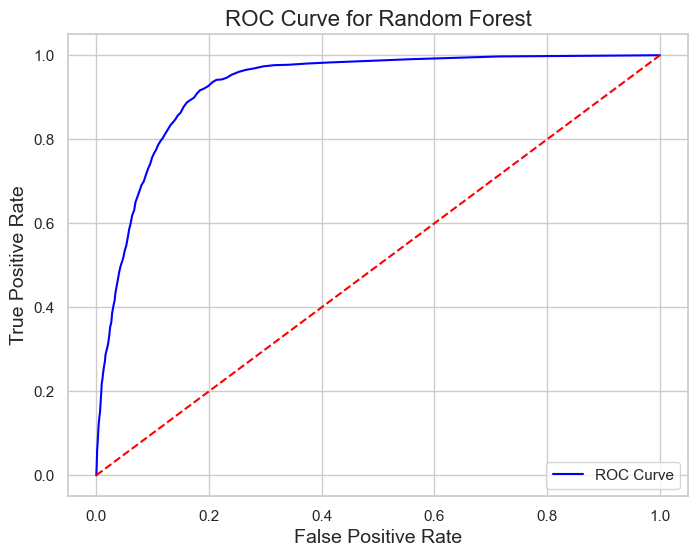

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for Random Forest', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


### Model Evaluation:

In General, This model did better than Decision Trees

#### 3.4 XGBoost

In [ ]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('XGB',XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:05:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.94      0.95      0.95      7985
         Yes       0.61      0.57      0.59      1058

    accuracy                           0.91      9043
   macro avg       0.78      0.76      0.77      9043
weighted avg       0.90      0.91      0.91      9043

ROC AUC : 0.93


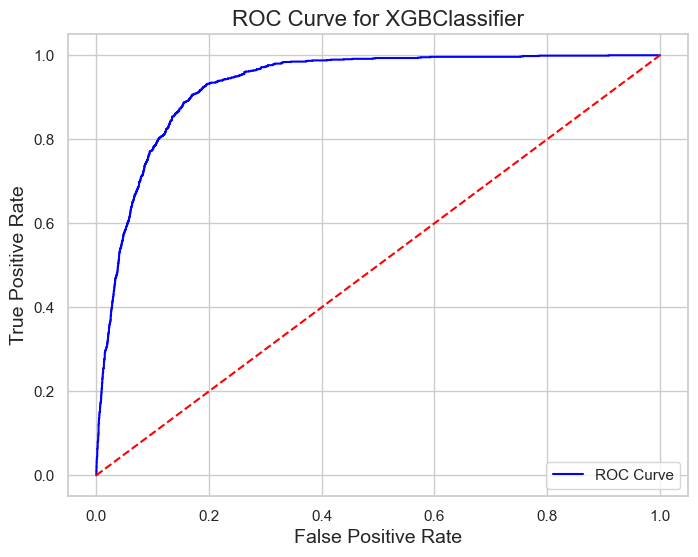

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for XGBClassifier', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


Comparing with previous model, for now, results are the best

#### 3.5 CatBoost

In [ ]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('CatBoost',CatBoostClassifier(verbose=0, random_state=42))
])


pipe.fit(Xtrain, Ytrain)
Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]


In [ ]:
from sklearn.metrics import roc_auc_score

print("                  ===Classification Report===")
print(classification_report(Ytest, Ypred, target_names=['No', 'Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, Yprob):.2f}")


                  ===Classification Report===
              precision    recall  f1-score   support

          No       0.94      0.96      0.95      7985
         Yes       0.63      0.57      0.60      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.76      0.77      9043
weighted avg       0.91      0.91      0.91      9043

ROC AUC : 0.93


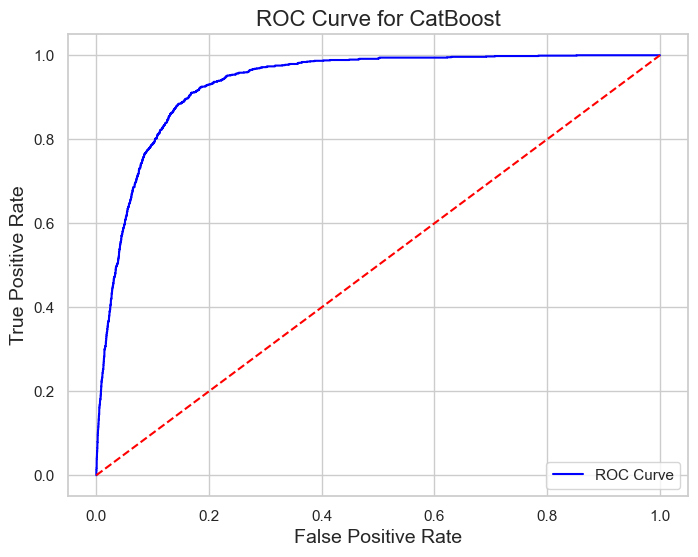

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Ytest, Yprob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.title('ROC Curve for CatBoost', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')


Good Results 

## 4. Results comparison (Сравнение результатов)

## Model Comparison

| Model | Accuracy | Precision (Yes) | Recall (Yes) | F1-score (Yes) | ROC AUC |
|---|---|---|---|---|---|
| **Logistic Regression** | 0.85 | 0.42 | **0.80** | 0.55 | 0.91 |
| **Decision Tree** | 0.87 | 0.44 | 0.54 | 0.48 | 0.72 |
| **Random Forest** | 0.90 | 0.58 | 0.55 | 0.56 | **0.93** |
| **XGBoost** | **0.91** | **0.68** | 0.57 | 0.59 | **0.93** |
| **CatBoost** | **0.91** | 0.63 | 0.57 | **0.60** | **0.93** |


---


### **Strengths and Weaknesses**

1. **Logistic Regression**
   - **Strengths:** High recall (0.80), simple, fast, easy to interpret.
   - **Weaknesses:** Low precision (0.42), misses specificity, cannot model nonlinear relationships.

2. **Decision Tree**
   - **Strengths:** Slightly better accuracy than LR, easy interpretability.
   - **Weaknesses:** Lowest ROC AUC (0.72), overfits easily, weak generalization.

3. **Random Forest**
   - **Strengths:** High accuracy (0.90), good precision (0.58), excellent ROC AUC (0.93), reduces overfitting compared to a single tree.
   - **Weaknesses:** Less interpretable, longer training time than LR or single tree.

4. **XGBoost**
   - **Strengths:** Highest precision (0.68), high accuracy (0.91), strong F1-score (0.59), excellent ROC AUC (0.93), handles complex data well.
   - **Weaknesses:** Requires careful hyperparameter tuning, less interpretable, longer training time.

5. **CatBoost**
   - **Strengths:** Highest F1-score (0.60), high precision (0.63), high accuracy (0.91), handles categorical features natively, excellent ROC AUC (0.93).
   - **Weaknesses:** Longer training time, slightly less widespread in industry compared to XGBoost.






### **Best Model Selection**

**CatBoost is chosen as the best model** for this task because:

✔️ It achieved the **highest F1-score (0.60)**, indicating the best balance between precision and recall.  
✔️ Its precision (0.63) and recall (0.57) are both high, leading to reliable predictions.  
✔️ It handles categorical features efficiently without complex preprocessing.  
✔️ Its ROC AUC (0.93) is equal to XGBoost and Random Forest, showing strong class separation.

 **In summary:** CatBoost provides **the most balanced and robust performance** for this classification task, making it the preferred choice.

## 5. Upgrading 2 best models

5.1 CatBoost

In [ ]:
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
import numpy as np

pipe_cb = ImbPipeline(steps=[
    ('prep',   preprocessor),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    CatBoostClassifier(verbose=0, random_state=42))
])

cv_scores_cb = cross_val_score(pipe_cb, Xtrain, Ytrain, 
                               cv=5, scoring='f1', n_jobs=-1)
print(f"CatBoost 5-Fold CV F1-score: {cv_scores_cb.mean():.3f} ± {cv_scores_cb.std():.3f}")


CatBoost 5-Fold CV F1-score: 0.596 ± 0.012


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_cb = {
    'clf__depth':          [3, 5, 7],
    'clf__learning_rate':  [0.01, 0.1, 0.2],
    'clf__iterations':     [100, 200]
}

grid_cb = GridSearchCV(pipe_cb, 
                       param_grid_cb, 
                       cv=5, 
                       scoring='f1',
                       n_jobs=-1,
                       verbose=1)
grid_cb.fit(Xtrain, Ytrain)

print("Best CatBoost Parameters:", grid_cb.best_params_)
print(f"Best CatBoost CV F1-score: {grid_cb.best_score_:.3f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CatBoost Parameters: {'clf__depth': 5, 'clf__iterations': 100, 'clf__learning_rate': 0.1}
Best CatBoost CV F1-score: 0.609


In [ ]:
final_cb = ImbPipeline(steps=[
    ('prep',   preprocessor),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    CatBoostClassifier(
                   verbose=0,
                   random_state=42,
                   depth=5,
                   iterations=100,
                   learning_rate=0.1
               ))
])

final_cb.fit(Xtrain, Ytrain)

y_pred_cb   = final_cb.predict(Xtest)
y_proba_cb  = final_cb.predict_proba(Xtest)[:, 1]



Exception ignored in: <function ResourceTracker.__del__ at 0x104c65440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104b91440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/m

         === Final CatBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      7985
           1       0.57      0.69      0.63      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.81      0.79      9043
weighted avg       0.91      0.90      0.91      9043

ROC AUC : 0.93


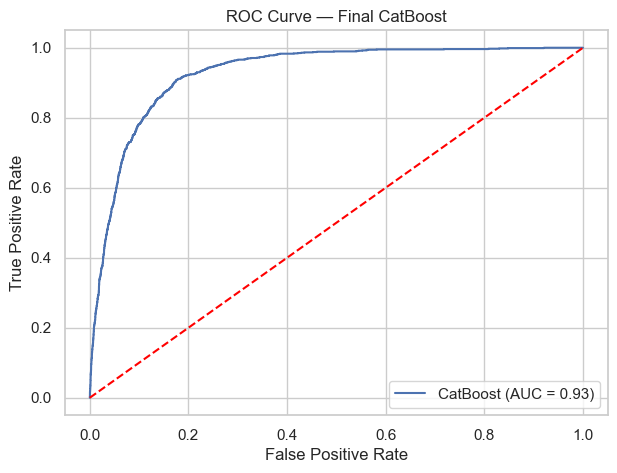

Exception ignored in: <function ResourceTracker.__del__ at 0x103091440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106359440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/m

In [ ]:
print("         === Final CatBoost Classification Report ===")
print(classification_report(Ytest, y_pred_cb))
print(f"ROC AUC : {roc_auc_score(Ytest, y_proba_cb):.2f}")

fpr, tpr, _ = roc_curve(Ytest, y_proba_cb)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {roc_auc_score(Ytest, y_proba_cb):.2f})')
plt.plot([0,1],[0,1],'--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final CatBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

5.2 XGBClassifier

In [ ]:
pipe_xgb = ImbPipeline(steps=[
    ('prep', preprocessor), 
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

scores = cross_val_score(
    pipe_xgb,
    Xtrain, Ytrain,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
print(f"XGBoost 5-Fold CV F1-score: {scores.mean():.3f} ± {scores.std():.3f}")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:26] WARN

XGBoost 5-Fold CV F1-score: 0.582 ± 0.013


In [ ]:
param_grid_xgb = {
    'clf__max_depth':       [3, 5, 7],
    'clf__learning_rate':   [0.01, 0.1, 0.2],
    'clf__n_estimators':    [100, 200],
    'clf__subsample':       [0.8, 1.0],
    'clf__colsample_bytree':[0.8, 1.0]
}

grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(Xtrain, Ytrain)

print("Best XGBoost Parameters:", grid_xgb.best_params_)
print(f"Best CV F1-score after tuning: {grid_xgb.best_score_:.3f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:49] WARN

Best XGBoost Parameters: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Best CV F1-score after tuning: 0.610


In [ ]:
final_xgb = ImbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        learning_rate=0.1,
        max_depth=7,
        n_estimators=100 ,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

final_xgb.fit(Xtrain, Ytrain)

y_pred = final_xgb.predict(Xtest)
y_proba = final_xgb.predict_proba(Xtest)[:, 1]





/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:19:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          === Final XGBoost Classification Report ===
              precision    recall  f1-score   support

          No       0.96      0.93      0.94      7985
         Yes       0.57      0.67      0.62      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.80      0.78      9043
weighted avg       0.91      0.90      0.91      9043

ROC AUC : 0.93


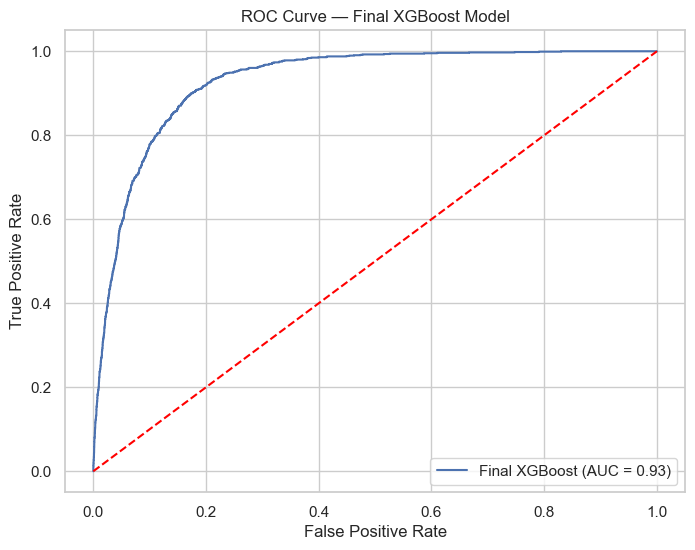

In [ ]:
print("          === Final XGBoost Classification Report ===")
print(classification_report(Ytest, y_pred, target_names=['No','Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, y_proba):.2f}")

fpr, tpr, _ = roc_curve(Ytest, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Final XGBoost (AUC = {roc_auc_score(Ytest, y_proba):.2f})')
plt.plot([0,1],[0,1],'--', color='red')
plt.title('ROC Curve — Final XGBoost Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Comparison

| Metric                  | CatBoost       | XGBoost        |
|-------------------------|----------------|----------------|
| **Accuracy**            | 0.90           | 0.90           |
| **Precision (Yes)**     | 0.57           | 0.57           |
| **Recall (Yes)**        | 0.69           | 0.67           |
| **F1-score (Yes)**      | 0.63           | 0.62           |
| **ROC AUC**             | 0.928          | 0.929          |
| **5-Fold CV F1**        | 0.596 ± 0.012  | 0.582 ± 0.013         |




Overall, both tuned CatBoost and XGBoost deliver very strong performance on this imbalanced classification task, achieving nearly identical accuracy (90%) and AUC (≈0.93). CatBoost pulls ahead with a slightly better F1-score (0.63 vs. 0.62) and higher recall (0.69 vs. 0.67) on the positive (“yes”) class, suggesting it strikes a marginally better balance between catching true positives and avoiding false alarms. XGBoost, in turn, edges out by a hair on AUC and often trains a bit faster, making it attractive when throughput is critical. If your highest priority is maximizing the F1-score on the minority class and you value native handling of categorical features, CatBoost is the way to go; if you need the smallest possible latency or align with an existing XGBoost-based pipeline, XGBoost remains an excellent choice.

In [102]:
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
import numpy as np

pipe_cb = ImbPipeline(steps=[
    ('prep',   preprocessor),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    CatBoostClassifier(verbose=0, random_state=42))
])

cv_scores_cb = cross_val_score(pipe_cb, Xtrain, Ytrain, 
                               cv=5, scoring='f1', n_jobs=-1)
print(f"CatBoost 5-Fold CV F1-score: {cv_scores_cb.mean():.3f} ± {cv_scores_cb.std():.3f}")


CatBoost 5-Fold CV F1-score: 0.596 ± 0.012


In [103]:
from sklearn.model_selection import GridSearchCV

param_grid_cb = {
    'clf__depth':          [3, 5, 7],
    'clf__learning_rate':  [0.01, 0.1, 0.2],
    'clf__iterations':     [100, 200]
}

grid_cb = GridSearchCV(pipe_cb, 
                       param_grid_cb, 
                       cv=5, 
                       scoring='f1',
                       n_jobs=-1,
                       verbose=1)
grid_cb.fit(Xtrain, Ytrain)

print("Best CatBoost Parameters:", grid_cb.best_params_)
print(f"Best CatBoost CV F1-score: {grid_cb.best_score_:.3f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CatBoost Parameters: {'clf__depth': 5, 'clf__iterations': 100, 'clf__learning_rate': 0.1}
Best CatBoost CV F1-score: 0.609


In [109]:
final_cb = ImbPipeline(steps=[
    ('prep',   preprocessor),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    CatBoostClassifier(
                   verbose=0,
                   random_state=42,
                   depth=5,
                   iterations=100,
                   learning_rate=0.1
               ))
])

final_cb.fit(Xtrain, Ytrain)

y_pred_cb   = final_cb.predict(Xtest)
y_proba_cb  = final_cb.predict_proba(Xtest)[:, 1]



Exception ignored in: <function ResourceTracker.__del__ at 0x104c65440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104b91440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/m

         === Final CatBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      7985
           1       0.57      0.69      0.63      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.81      0.79      9043
weighted avg       0.91      0.90      0.91      9043

ROC AUC : 0.93


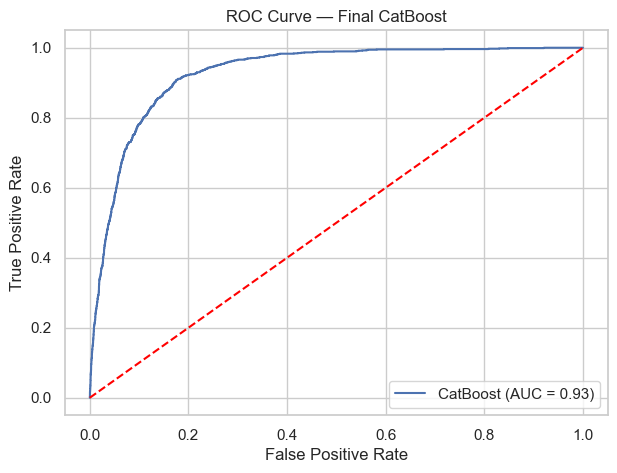

Exception ignored in: <function ResourceTracker.__del__ at 0x103091440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106359440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/m

In [118]:
print("         === Final CatBoost Classification Report ===")
print(classification_report(Ytest, y_pred_cb))
print(f"ROC AUC : {roc_auc_score(Ytest, y_proba_cb):.2f}")

fpr, tpr, _ = roc_curve(Ytest, y_proba_cb)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {roc_auc_score(Ytest, y_proba_cb):.2f})')
plt.plot([0,1],[0,1],'--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final CatBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

5.2 XGBClassifier

In [111]:
pipe_xgb = ImbPipeline(steps=[
    ('prep', preprocessor), 
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

scores = cross_val_score(
    pipe_xgb,
    Xtrain, Ytrain,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
print(f"XGBoost 5-Fold CV F1-score: {scores.mean():.3f} ± {scores.std():.3f}")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:26] WARN

XGBoost 5-Fold CV F1-score: 0.582 ± 0.013


In [112]:
param_grid_xgb = {
    'clf__max_depth':       [3, 5, 7],
    'clf__learning_rate':   [0.01, 0.1, 0.2],
    'clf__n_estimators':    [100, 200],
    'clf__subsample':       [0.8, 1.0],
    'clf__colsample_bytree':[0.8, 1.0]
}

grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(Xtrain, Ytrain)

print("Best XGBoost Parameters:", grid_xgb.best_params_)
print(f"Best CV F1-score after tuning: {grid_xgb.best_score_:.3f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:15:49] WARN

Best XGBoost Parameters: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Best CV F1-score after tuning: 0.610


In [113]:
final_xgb = ImbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        learning_rate=0.1,
        max_depth=7,
        n_estimators=100 ,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

final_xgb.fit(Xtrain, Ytrain)

y_pred = final_xgb.predict(Xtest)
y_proba = final_xgb.predict_proba(Xtest)[:, 1]





/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [20:19:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          === Final XGBoost Classification Report ===
              precision    recall  f1-score   support

          No       0.96      0.93      0.94      7985
         Yes       0.57      0.67      0.62      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.80      0.78      9043
weighted avg       0.91      0.90      0.91      9043

ROC AUC : 0.93


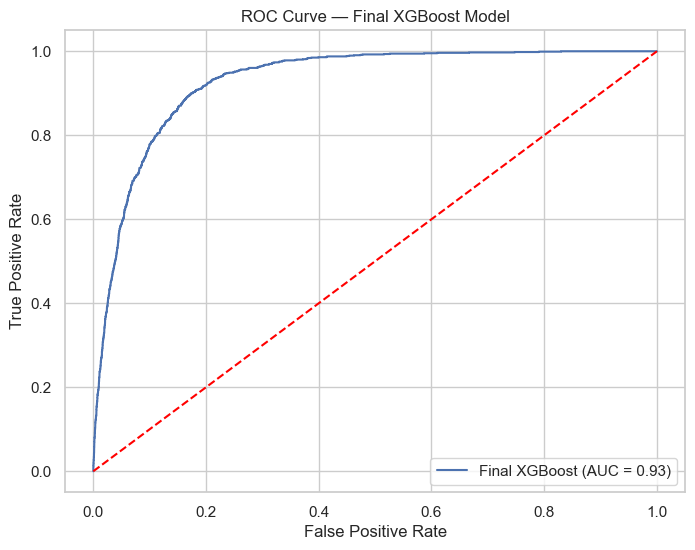

In [117]:
print("          === Final XGBoost Classification Report ===")
print(classification_report(Ytest, y_pred, target_names=['No','Yes']))
print(f"ROC AUC : {roc_auc_score(Ytest, y_proba):.2f}")

fpr, tpr, _ = roc_curve(Ytest, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Final XGBoost (AUC = {roc_auc_score(Ytest, y_proba):.2f})')
plt.plot([0,1],[0,1],'--', color='red')
plt.title('ROC Curve — Final XGBoost Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

##  Comparison

| Metric                  | CatBoost       | XGBoost        |
|-------------------------|----------------|----------------|
| **Accuracy**            | 0.90           | 0.90           |
| **Precision (Yes)**     | 0.57           | 0.57           |
| **Recall (Yes)**        | 0.69           | 0.67           |
| **F1-score (Yes)**      | 0.63           | 0.62           |
| **ROC AUC**             | 0.928          | 0.929          |
| **5-Fold CV F1**        | 0.596 ± 0.012  |  0.582 ± 0.013         |




Overall, both tuned CatBoost and XGBoost deliver very strong performance on this imbalanced classification task, achieving nearly identical accuracy (90%) and AUC (≈0.93). CatBoost pulls ahead with a slightly better F1-score (0.63 vs. 0.62) and higher recall (0.69 vs. 0.67) on the positive (“yes”) class, suggesting it strikes a marginally better balance between catching true positives and avoiding false alarms. XGBoost, in turn, edges out by a hair on AUC and often trains a bit faster, making it attractive when throughput is critical. If your highest priority is maximizing the F1-score on the minority class and you value native handling of categorical features, CatBoost is the way to go; if you need the smallest possible latency or align with an existing XGBoost-based pipeline, XGBoost remains an excellent choice.